#  Title: Implementation of Decision Tree Classifier using R

###  Algorithm: Recursive Partitioning (rpart)
###  Dataset: iris (built-in)

#  1. Install & Load Libraries

In [1]:
if (!require(rpart))        install.packages("rpart",        repos="https://cran.r-project.org")
if (!require(rpart.plot))   install.packages("rpart.plot",   repos="https://cran.r-project.org")
if (!require(caret))        install.packages("caret",        repos="https://cran.r-project.org")
if (!require(ggplot2))      install.packages("ggplot2",      repos="https://cran.r-project.org")

library(rpart)
library(rpart.plot)
library(caret)
library(ggplot2)

Loading required package: rpart

Loading required package: rpart.plot

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘rpart.plot’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Loading required package: caret

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘caret’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘listenv’, ‘parallelly’, ‘future’, ‘globals’, ‘shape’, ‘future.apply’, ‘numDeriv’, ‘progressr’, ‘SQUAREM’, ‘diagram’, ‘lava’, ‘prodlim’, ‘proxy’, ‘iterators’, ‘clock’, ‘gower’, ‘hardhat’, ‘ipred’, ‘sparsevctrs’, ‘timeDate’, ‘e1071’, ‘foreach’, ‘ModelMetrics’, ‘plyr’, ‘pROC’, ‘recipes’, ‘reshape2’


Loading required package: ggplot2

Loading required package: lattice



# 2. Load & Explore Dataset

In [2]:
dataset <- iris

cat("===== Dataset Overview =====\n")
cat("Dimensions:", nrow(dataset), "rows x", ncol(dataset), "columns\n")
str(dataset)

cat("\n===== Class Distribution =====\n")
print(table(dataset$Species))

===== Dataset Overview =====
Dimensions: 150 rows x 5 columns
'data.frame':	150 obs. of  5 variables:
 $ Sepal.Length: num  5.1 4.9 4.7 4.6 5 5.4 4.6 5 4.4 4.9 ...
 $ Sepal.Width : num  3.5 3 3.2 3.1 3.6 3.9 3.4 3.4 2.9 3.1 ...
 $ Petal.Length: num  1.4 1.4 1.3 1.5 1.4 1.7 1.4 1.5 1.4 1.5 ...
 $ Petal.Width : num  0.2 0.2 0.2 0.2 0.2 0.4 0.3 0.2 0.2 0.1 ...
 $ Species     : Factor w/ 3 levels "setosa","versicolor",..: 1 1 1 1 1 1 1 1 1 1 ...

===== Class Distribution =====

    setosa versicolor  virginica 
        50         50         50 


# 3. Train / Test Split

In [3]:
set.seed(123)
train_index <- createDataPartition(dataset$Species, p = 0.70, list = FALSE)
train_data  <- dataset[ train_index, ]
test_data   <- dataset[-train_index, ]

cat("\n===== Split Sizes =====\n")
cat("Training set:", nrow(train_data), "\n")
cat("Test set    :", nrow(test_data),  "\n")


===== Split Sizes =====
Training set: 105 
Test set    : 45 


# 4. Calculate Conditional Probability (Gini / Entropy)

In [4]:
# Manual Entropy calculation for a feature split
entropy <- function(labels) {
  freq <- table(labels) / length(labels)
  freq <- freq[freq > 0]
  -sum(freq * log2(freq))
}

# Manual Gini Impurity
gini <- function(labels) {
  freq <- table(labels) / length(labels)
  1 - sum(freq^2)
}

cat("\n===== Entropy of Target (full training set) =====\n")
cat("H(Species) =", round(entropy(train_data$Species), 4), "\n")

cat("\n===== Gini Impurity of Target (full training set) =====\n")
cat("Gini(Species) =", round(gini(train_data$Species), 4), "\n")

# Information gain for a split on Petal.Length at threshold 2.45
split_threshold <- 2.45
left  <- train_data[train_data$Petal.Length <= split_threshold, "Species"]
right <- train_data[train_data$Petal.Length >  split_threshold, "Species"]

n      <- nrow(train_data)
n_left <- length(left)
n_right<- length(right)

H_parent <- entropy(train_data$Species)
H_left   <- entropy(left)
H_right  <- entropy(right)
IG       <- H_parent - (n_left/n * H_left) - (n_right/n * H_right)

cat("\n===== Information Gain: Petal.Length <= 2.45 =====\n")
cat("H(parent)   =", round(H_parent, 4), "\n")
cat("H(left)     =", round(H_left,   4), "\n")
cat("H(right)    =", round(H_right,  4), "\n")
cat("Info Gain   =", round(IG,       4), "\n")


===== Entropy of Target (full training set) =====
H(Species) = 1.585 

===== Gini Impurity of Target (full training set) =====
Gini(Species) = 0.6667 

===== Information Gain: Petal.Length <= 2.45 =====
H(parent)   = 1.585 
H(left)     = 0 
H(right)    = 1 
Info Gain   = 0.9183 


# 5. Build Decision Tree

In [5]:
# Method: "class" for classification, "gini" splitting criterion
dt_model_gini <- rpart(Species ~ .,
                        data    = train_data,
                        method  = "class",
                        parms   = list(split = "gini"),
                        control = rpart.control(minsplit = 5,
                                                cp       = 0.01))

dt_model_info <- rpart(Species ~ .,
                        data    = train_data,
                        method  = "class",
                        parms   = list(split = "information"),
                        control = rpart.control(minsplit = 5,
                                                cp       = 0.01))

cat("\n===== Decision Tree (Gini) Summary =====\n")
print(dt_model_gini)

cat("\n===== Variable Importance =====\n")
print(dt_model_gini$variable.importance)


===== Decision Tree (Gini) Summary =====
n= 105 

node), split, n, loss, yval, (yprob)
      * denotes terminal node

 1) root 105 70 setosa (0.33333333 0.33333333 0.33333333)  
   2) Petal.Length< 2.6 35  0 setosa (1.00000000 0.00000000 0.00000000) *
   3) Petal.Length>=2.6 70 35 versicolor (0.00000000 0.50000000 0.50000000)  
     6) Petal.Width< 1.65 36  2 versicolor (0.00000000 0.94444444 0.05555556)  
      12) Petal.Length< 5.35 34  0 versicolor (0.00000000 1.00000000 0.00000000) *
      13) Petal.Length>=5.35 2  0 virginica (0.00000000 0.00000000 1.00000000) *
     7) Petal.Width>=1.65 34  1 virginica (0.00000000 0.02941176 0.97058824) *

===== Variable Importance =====
 Petal.Width Petal.Length Sepal.Length  Sepal.Width 
    64.28105     62.89158     40.91811     23.75087 


# 6. Visualize the Tree

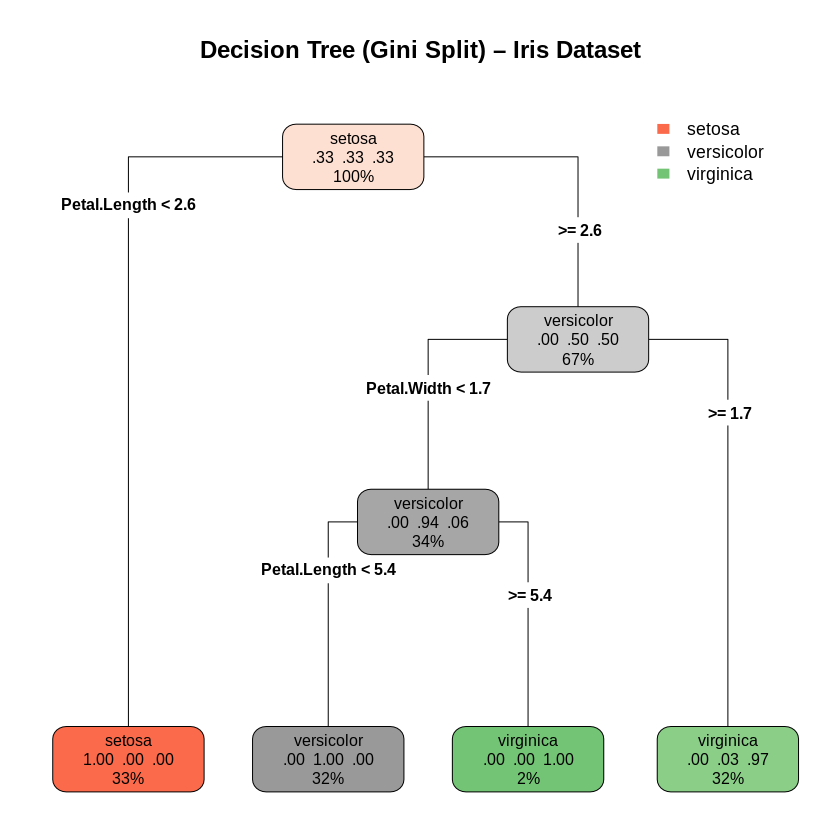

In [6]:
rpart.plot(dt_model_gini,
           type  = 4,
           extra = 104,
           main  = "Decision Tree (Gini Split) – Iris Dataset",
           cex   = 0.8)

# 7. Classify Test Samples

In [7]:
predictions <- predict(dt_model_gini, test_data, type = "class")

# 8. Display Predicted vs Actual Values

In [8]:
cat("\n===== Predicted vs Actual Values =====\n")
results_df <- data.frame(
  Index     = 1:nrow(test_data),
  Actual    = test_data$Species,
  Predicted = predictions,
  Match     = ifelse(test_data$Species == predictions, "✓ Correct", "✗ Wrong")
)
print(results_df)


===== Predicted vs Actual Values =====
    Index     Actual  Predicted     Match
1       1     setosa     setosa ✓ Correct
2       2     setosa     setosa ✓ Correct
6       3     setosa     setosa ✓ Correct
16      4     setosa     setosa ✓ Correct
18      5     setosa     setosa ✓ Correct
20      6     setosa     setosa ✓ Correct
22      7     setosa     setosa ✓ Correct
23      8     setosa     setosa ✓ Correct
34      9     setosa     setosa ✓ Correct
35     10     setosa     setosa ✓ Correct
38     11     setosa     setosa ✓ Correct
39     12     setosa     setosa ✓ Correct
44     13     setosa     setosa ✓ Correct
46     14     setosa     setosa ✓ Correct
47     15     setosa     setosa ✓ Correct
51     16 versicolor versicolor ✓ Correct
53     17 versicolor versicolor ✓ Correct
54     18 versicolor versicolor ✓ Correct
64     19 versicolor versicolor ✓ Correct
72     20 versicolor versicolor ✓ Correct
74     21 versicolor versicolor ✓ Correct
78     22 versicolor  virginica   ✗ 

# 9. Model Evaluation

In [9]:
cm <- confusionMatrix(predictions, test_data$Species)
cat("\n===== Confusion Matrix =====\n")
print(cm)

cat("\n===== Key Metrics =====\n")
cat("Accuracy :", round(cm$overall["Accuracy"], 4), "\n")
cat("Kappa    :", round(cm$overall["Kappa"],    4), "\n")


===== Confusion Matrix =====
Confusion Matrix and Statistics

            Reference
Prediction   setosa versicolor virginica
  setosa         15          0         0
  versicolor      0         14         2
  virginica       0          1        13

Overall Statistics
                                         
               Accuracy : 0.9333         
                 95% CI : (0.8173, 0.986)
    No Information Rate : 0.3333         
    P-Value [Acc > NIR] : < 2.2e-16      
                                         
                  Kappa : 0.9            
                                         
 Mcnemar's Test P-Value : NA             

Statistics by Class:

                     Class: setosa Class: versicolor Class: virginica
Sensitivity                 1.0000            0.9333           0.8667
Specificity                 1.0000            0.9333           0.9667
Pos Pred Value              1.0000            0.8750           0.9286
Neg Pred Value              1.0000            0.96

# 10. Pruning


===== CP Table (for Pruning) =====

Classification tree:
rpart(formula = Species ~ ., data = train_data, method = "class", 
    parms = list(split = "gini"), control = rpart.control(minsplit = 5, 
        cp = 0.01))

Variables actually used in tree construction:
[1] Petal.Length Petal.Width 

Root node error: 70/105 = 0.66667

n= 105 

        CP nsplit rel error  xerror     xstd
1 0.500000      0  1.000000 1.27143 0.052609
2 0.457143      1  0.500000 0.75714 0.073189
3 0.028571      2  0.042857 0.10000 0.036515
4 0.010000      3  0.014286 0.10000 0.036515

Best CP value: 0.02857143 


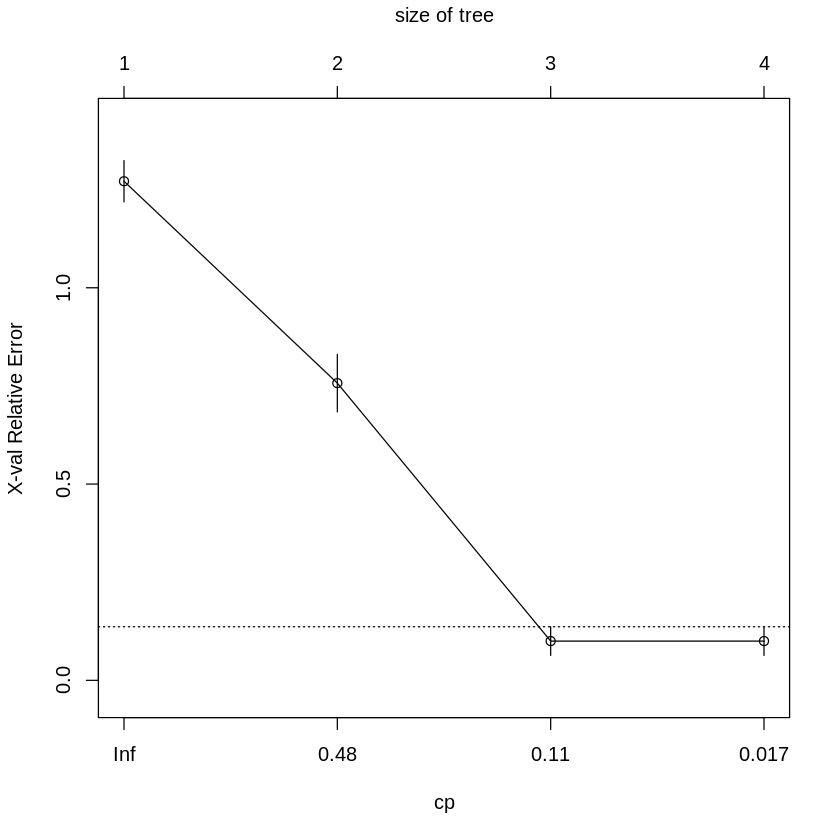

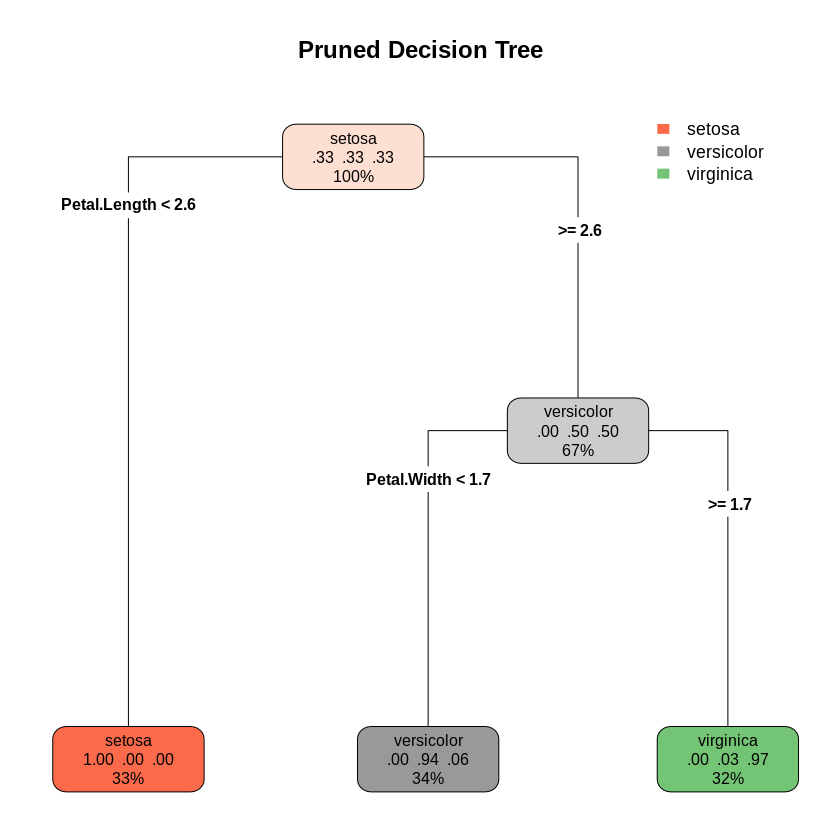

In [10]:
cat("\n===== CP Table (for Pruning) =====\n")
printcp(dt_model_gini)
plotcp(dt_model_gini)

# Prune to the optimal cp
best_cp    <- dt_model_gini$cptable[which.min(dt_model_gini$cptable[, "xerror"]), "CP"]
pruned_tree <- prune(dt_model_gini, cp = best_cp)

cat("\nBest CP value:", best_cp, "\n")
rpart.plot(pruned_tree,
           type  = 4,
           extra = 104,
           main  = "Pruned Decision Tree",
           cex   = 0.8)

# 11. Compare with Information Gain tree

In [11]:
pred_info <- predict(dt_model_info, test_data, type = "class")
cm_info   <- confusionMatrix(pred_info, test_data$Species)
cat("\nAccuracy (Gini)             :", round(cm$overall["Accuracy"],      4), "\n")
cat("Accuracy (Information Gain) :", round(cm_info$overall["Accuracy"],  4), "\n")


Accuracy (Gini)             : 0.9333 
Accuracy (Information Gain) : 0.9333 
